# Chronic Kidney Disease Prediction — XGBoost
Dataset: Chronic Kidney Disease (OpenML)
Task: Binary classification — CKD vs not-CKD

In [5]:
import subprocess
subprocess.run(['pip', 'install', 'ucimlrepo', '-q'], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb
import shap
import joblib
import os
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Setup complete')

Setup complete


In [6]:
# Fetch CKD dataset from UCI (id=336) — OpenML does not host this dataset reliably
ckd = fetch_ucirepo(id=336)
df = ckd.data.features.copy()
df['class'] = ckd.data.targets.values.ravel()   # merge target into df
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Target values:', df['class'].unique())
print('Missing per column:\n', df.isnull().sum())
df.head()

Shape: (400, 25)
Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']
Target values: <StringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str
Missing per column:
 age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [7]:
df['target'] = (df['class'].astype(str).str.lower().str.strip() == 'ckd').astype(int)
df = df.drop(columns=['class'])

# Encode all categorical columns with LabelEncoder
# Cast to object first — fetch_openml returns Categorical dtype which
# rejects .loc assignment of integer codes without updating categories list
for col in df.select_dtypes(include=['category', 'object']).columns:
    if col == 'target':
        continue
    df[col] = df[col].astype(object)          # strip Categorical dtype
    le = LabelEncoder()
    mask = df[col].notna()
    df.loc[mask, col] = le.fit_transform(df.loc[mask, col].astype(str))
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values with median
feature_names = [c for c in df.columns if c != 'target']
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df[feature_names].astype(float))
y = df['target'].values
print('Features:', feature_names)
print('Class distribution:', np.bincount(y))

Features: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Class distribution: [150 250]


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 320 | Test: 80


In [9]:
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('Training complete')

[0]	validation_0-logloss:0.62273
[50]	validation_0-logloss:0.07882
[100]	validation_0-logloss:0.03059
[150]	validation_0-logloss:0.02410
[200]	validation_0-logloss:0.02341
[250]	validation_0-logloss:0.02397
[299]	validation_0-logloss:0.02504
Training complete


In [10]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not CKD', 'CKD']))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Accuracy : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

5-Fold CV ROC-AUC: 0.9980 (+/- 0.0021)


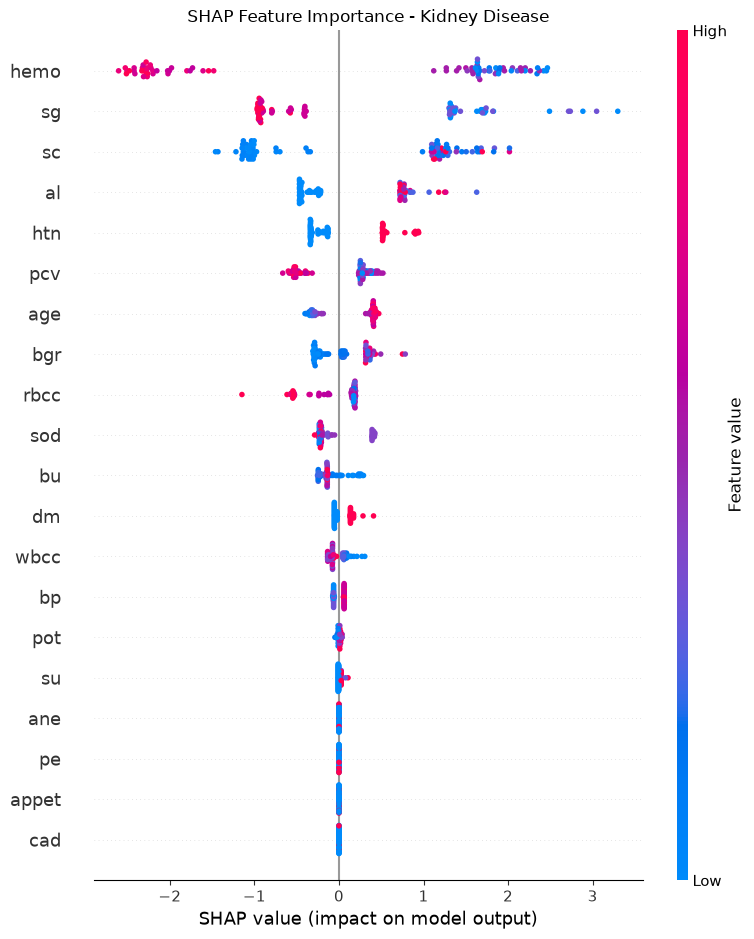

SHAP plot saved


In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Kidney Disease')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/kidney_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved')

In [12]:
joblib.dump(model,         f'{MODEL_DIR}/kidney_model.pkl')
joblib.dump(scaler,        f'{MODEL_DIR}/kidney_scaler.pkl')
joblib.dump(feature_names, f'{MODEL_DIR}/kidney_features.pkl')
joblib.dump(imputer,       f'{MODEL_DIR}/kidney_imputer.pkl')
for fname in ['kidney_model.pkl', 'kidney_scaler.pkl', 'kidney_features.pkl', 'kidney_imputer.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{fname}') / 1024
    print(f'  {fname}  ({size:.1f} KB)')
print('All kidney artifacts saved!')

  kidney_model.pkl  (255.0 KB)
  kidney_scaler.pkl  (1.1 KB)
  kidney_features.pkl  (0.2 KB)
  kidney_imputer.pkl  (1.1 KB)
All kidney artifacts saved!
